In [1]:
import os
os.chdir('/Users/taruni/Desktop/virality-prediction-ml-2026')
print('Working directory:', os.getcwd())

Working directory: /Users/taruni/Desktop/virality-prediction-ml-2026


# 05 — Fairness Audit
Compare Recall and F1 across platforms and content types

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
print('TODO: slice predictions by platform and content type')

TODO: slice predictions by platform and content type


In [3]:
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, recall_score, precision_score

# Load master data
master_df = pd.read_csv('data/processed/master.csv')

# Fix day_of_week
day_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
           'Friday': 4, 'Saturday': 5, 'Sunday': 6}
master_df['day_of_week'] = master_df['day_of_week'].map(day_map).fillna(master_df['day_of_week'])
master_df['day_of_week'] = pd.to_numeric(master_df['day_of_week'], errors='coerce').fillna(0).astype(int)

X = master_df.drop(columns=['viral', 'engagement_rate'])
y = master_df['viral']

scaler = pickle.load(open('data/processed/scaler.pkl', 'rb'))
X_scaled = scaler.transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

# Load best model - Random Forest
rf = pickle.load(open('data/processed/model_rf.pkl', 'rb'))

# Get predictions on test set
rf_preds = rf.predict(X_test)

# Rebuild test dataframe with platform info
test_df = master_df.iloc[y_test.index].copy()
test_df['predicted'] = rf_preds
test_df['actual'] = y_test.values

print('Loaded! Test set size:', len(test_df))
print(test_df['platform_instagram'].sum(), 'Instagram posts in test set')

/var/folders/dq/d0m2jdg97tsbddmx7x2s3rr80000gn/T/ipykernel_85551/1134553667.py:8: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  master_df = pd.read_csv('data/processed/master.csv')


Loaded! Test set size: 18007
6133 Instagram posts in test set


In [4]:
# ── FAIRNESS AUDIT BY PLATFORM ──

platforms = {
    'Instagram': test_df['platform_instagram'] == 1,
    'YouTube':   test_df['platform_youtube'] == 1,
    'TikTok':    test_df['platform_tiktok'] == 1
}

print("=== FAIRNESS AUDIT — BY PLATFORM ===\n")
fairness_results = []

for platform, mask in platforms.items():
    subset = test_df[mask]
    actual = subset['actual']
    predicted = subset['predicted']
    
    f1  = round(f1_score(actual, predicted), 4)
    rec = round(recall_score(actual, predicted), 4)
    pre = round(precision_score(actual, predicted), 4)
    
    fairness_results.append({
        'Platform': platform,
        'Posts': len(subset),
        'Viral Posts': actual.sum(),
        'Precision': pre,
        'Recall': rec,
        'F1': f1
    })
    print(f"--- {platform} ---")
    print(f"  Posts: {len(subset)}, Viral: {actual.sum()}")
    print(f"  Precision: {pre}, Recall: {rec}, F1: {f1}")
    print()

fairness_df = pd.DataFrame(fairness_results)
print(fairness_df.to_string(index=False))

=== FAIRNESS AUDIT — BY PLATFORM ===

--- Instagram ---
  Posts: 6133, Viral: 1191
  Precision: 0.2064, Recall: 0.0487, F1: 0.0788

--- YouTube ---
  Posts: 8114, Viral: 1624
  Precision: 0.7973, Recall: 0.8768, F1: 0.8352

--- TikTok ---
  Posts: 3760, Viral: 779
  Precision: 0.273, Recall: 0.5327, F1: 0.361

 Platform  Posts  Viral Posts  Precision  Recall     F1
Instagram   6133         1191     0.2064  0.0487 0.0788
  YouTube   8114         1624     0.7973  0.8768 0.8352
   TikTok   3760          779     0.2730  0.5327 0.3610


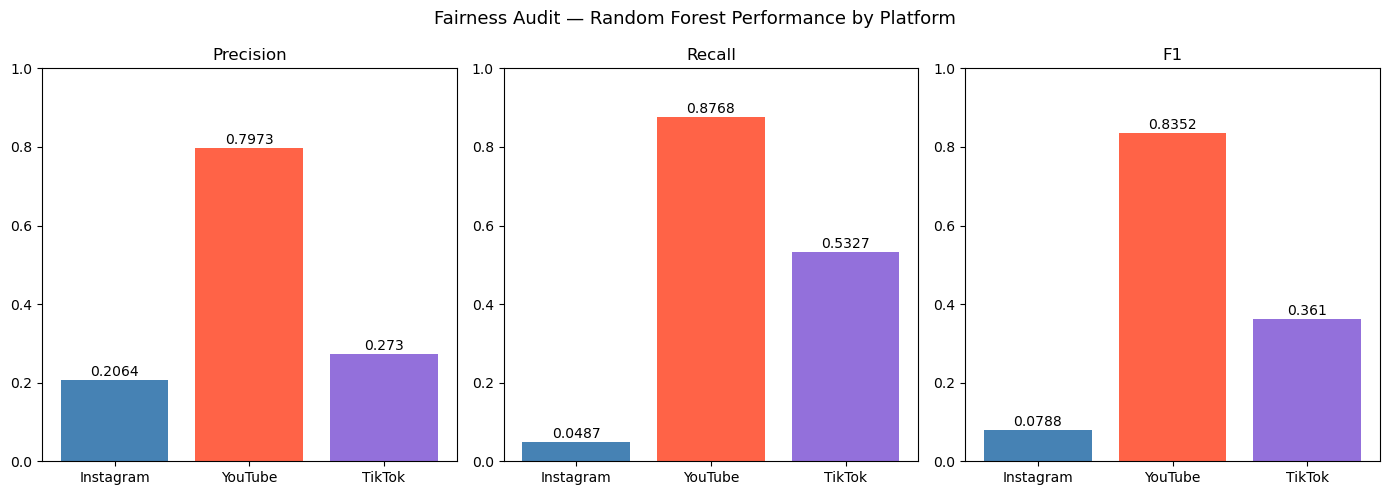

Saved!


In [5]:
# ── FAIRNESS AUDIT PLOT ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Fairness Audit — Random Forest Performance by Platform', fontsize=13)

metrics = ['Precision', 'Recall', 'F1']
colors  = ['steelblue', 'tomato', 'mediumpurple']

for i, metric in enumerate(metrics):
    axes[i].bar(fairness_df['Platform'], fairness_df[metric], color=colors)
    axes[i].set_title(metric)
    axes[i].set_ylim(0, 1)
    for j, v in enumerate(fairness_df[metric]):
        axes[i].text(j, v + 0.01, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('notebooks/fairness_audit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved!')